### Importing Libraries

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import sqlalchemy
import warnings
warnings.filterwarnings("ignore")

### Setting up Connection

In [24]:
# Setting  up connection and checking the names of tables
conn = sqlite3.connect("travel.sqlite") 
cursor = conn.cursor()  

### Top 2 Rows of each tables

In [25]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type= 'table'",conn).reset_index()
for table in tables["name"]:
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 2", conn)
    
    print(f"\nTable: {table}")
    print("-"*60)
    print(df)


Table: aircrafts_data
------------------------------------------------------------
  aircraft_code                                            model  range
0           773  {"en": "Boeing 777-300", "ru": "Боинг 777-300"}  11100
1           763  {"en": "Boeing 767-300", "ru": "Боинг 767-300"}   7900

Table: airports_data
------------------------------------------------------------
  airport_code                               airport_name  \
0          YKS  {"en": "Yakutsk Airport", "ru": "Якутск"}   
1          MJZ    {"en": "Mirny Airport", "ru": "Мирный"}   

                                city                              coordinates  \
0  {"en": "Yakutsk", "ru": "Якутск"}    (129.77099609375,62.0932998657226562)   
1   {"en": "Mirnyj", "ru": "Мирный"}  (114.03900146484375,62.534698486328125)   

       timezone  
0  Asia/Yakutsk  
1  Asia/Yakutsk  

Table: boarding_passes
------------------------------------------------------------
       ticket_no  flight_id  boarding_no seat_no
0

### Data Type of each table

In [26]:
for table in tables["name"]:
    df=pd.read_sql_query(f"Select * from {table} Limit 1",conn)
    print("xx"*50)
    print(table)
    print("-"*50)
    print(df.dtypes)
    print("xx"*50)

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
aircrafts_data
--------------------------------------------------
aircraft_code      str
model              str
range            int64
dtype: object
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
airports_data
--------------------------------------------------
airport_code    str
airport_name    str
city            str
coordinates     str
timezone        str
dtype: object
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
boarding_passes
--------------------------------------------------
ticket_no        str
flight_id      int64
boarding_no    int64
seat_no          str
dtype: object
xx

### Nulls in each table

In [27]:
for table in tables["name"]:
    df=pd.read_sql_query(f"Select * from {table} ",conn)
    print("xx"*50)
    print(table)
    print("-"*50)
    print(df.isnull().sum())
    print("xx"*50)

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
aircrafts_data
--------------------------------------------------
aircraft_code    0
model            0
range            0
dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
airports_data
--------------------------------------------------
airport_code    0
airport_name    0
city            0
coordinates     0
timezone        0
dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
boarding_passes
--------------------------------------------------
ticket_no      0
flight_id      0
boarding_no    0
seat_no        0
dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

### Aircrafts which have more than 100 seats

In [28]:
pd.read_sql_query(f"""SELECT aircraft_code, COUNT(*) as num_seats FROM seats 
                        GROUP BY aircraft_code 
                        HAVING num_seats > 100 
                        ORDER BY num_seats DESC""", conn)

,aircraft_code,num_seats
0,773,402
1,763,222
2,321,170
3,320,140
4,733,130
5,319,116


### How the number of tickets booked and Total amount earned changed over time

In [40]:
# Changin data type and grouping up by Month
df = pd.read_sql_query("Select t.ticket_no,b.book_date, b.total_amount from bookings as b inner join tickets as t on b.book_ref = t.book_ref ",conn)
df["book_date"]=pd.to_datetime(df["book_date"])  # Changing Book date from string to Datetime format
df["book_date"] = df["book_date"].dt.date
merged = df.groupby("book_date").agg({"ticket_no":"count","total_amount":"sum"}).rename(columns={"ticket_no":"Number of tickets", "total_amount":"Amount_earned"})

#Converting Numbers into M and K 
def con_m(x):
    if x > 1_000_000:
        return f"{round(x/1_000_000, 2)}M"
    elif x > 1_000:
        return f"{round(x/1_000, 2)}K"
    else:
        return str(x)
    
merged["Amount_earned"]=merged["Amount_earned"].apply(con_m)
merged["Number of tickets"]= merged["Number of tickets"].apply(con_m)
df.head()


,ticket_no,book_date,total_amount
0,0005435838975,2017-07-05,265700
1,0005432527326,2017-07-14,37900
2,0005432293273,2017-08-15,18100
3,0005435545944,2017-08-10,131800
4,0005435545945,2017-08-10,131800


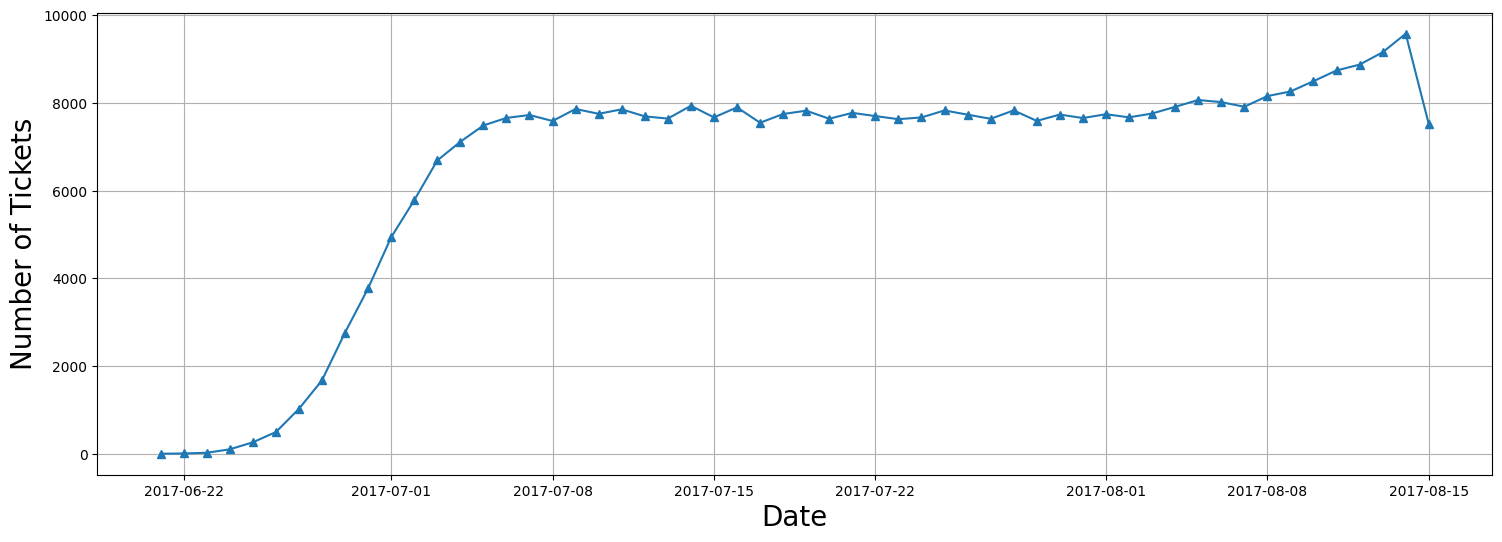

In [ ]:
# Time Analysis for Number of ticket booked
tickets = pd.read_sql_query(f"""SELECT *
                                    FROM tickets
                                    INNER JOIN bookings 
                                    ON tickets.book_ref=bookings.book_ref;""", conn)
tickets['book_date'] = pd.to_datetime(tickets['book_date'])
tickets['date'] = tickets['book_date'].dt.date
x =  tickets.groupby('date')[['date']].count()
plt.figure(figsize = (18,6))
plt.plot(x.index,x['date'], marker = '^')
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Number of Tickets', fontsize = 20)
plt.grid('b')
plt.show()

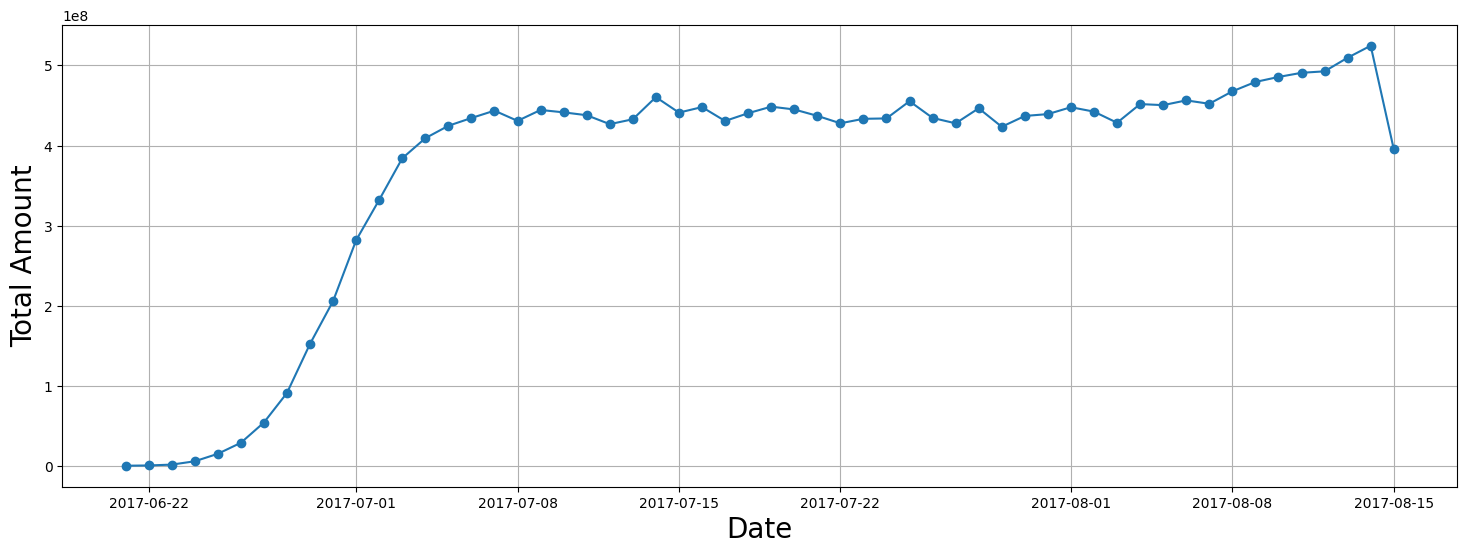

In [42]:
# Time analysis for Revenue earned
bookings = pd.read_sql_query(f"""SELECT * FROM bookings""", conn)
bookings['book_date'] = pd.to_datetime(bookings['book_date'])
bookings['date'] = bookings['book_date'].dt.date
y =  bookings.groupby('date')[['total_amount']].sum()
plt.figure(figsize = (18,6))
plt.plot(y.index,y['total_amount'], marker = 'o')
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Total Amount', fontsize = 20)
plt.grid('b')
plt.show()

### Average Charges for each Aircraft with different fare conditions

In [43]:
# Joining tables to get Aircraft Code
df =  pd.read_sql_query( """ 
Select 
f.aircraft_code,
f.flight_id,
tf.fare_conditions,
tf.amount
from ticket_flights as tf 
join flights as f 
on f.flight_id = tf.flight_id
""",
conn)


In [44]:
# Grouping by Aircraft code and Class
merged=df.groupby(["aircraft_code","fare_conditions"]).agg({"amount":"mean"}).rename(columns={"fare_conditions":"Class","amount":"Amount_Earned"})
df = merged["Amount_Earned"].apply(con_m)
df

aircraft_code  fare_conditions
319            Business           113.55K
               Economy             38.31K
321            Business            34.44K
               Economy             11.53K
733            Business            41.87K
               Economy             13.99K
763            Business            82.84K
               Economy             27.59K
773            Business            57.78K
               Comfort             32.74K
               Economy             19.27K
CN1            Economy              6.57K
CR2            Economy             13.21K
SU9            Business            33.49K
               Economy             11.22K
Name: Amount_Earned, dtype: str

<Axes: xlabel='aircraft_code', ylabel='Amount_Earned'>

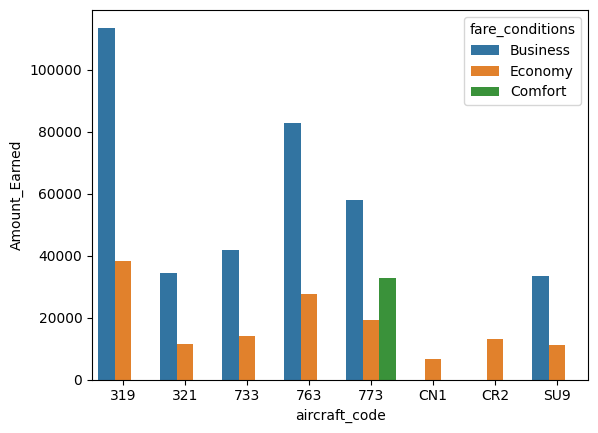

In [45]:
sns.barplot(data=merged,x="aircraft_code",y="Amount_Earned",hue="fare_conditions")

# Analyzing occupancy rate

**For each aircraft, calculate the total revenue per year and the average revenue per ticket.**

In [46]:
pd.set_option('display.float_format', str)

In [47]:
pd.read_sql_query(f"""SELECT aircraft_code, total_revenue, ticket_count, total_revenue/ticket_count as avg_revenue_per_ticket
                        FROM 
                        (SELECT aircraft_code, COUNT(*) as ticket_count, SUM(amount) as total_revenue  FROM ticket_flights
                        JOIN flights 
                        ON ticket_flights.flight_id=flights.flight_id 
                        GROUP BY aircraft_code)""", conn)

,aircraft_code,total_revenue,ticket_count,avg_revenue_per_ticket
0,319,2706163100,52853,51201
1,321,1638164100,107129,15291
2,733,1426552100,86102,16568
3,763,4371277100,124774,35033
4,773,3431205500,144376,23765
5,CN1,96373800,14672,6568
6,CR2,1982760500,150122,13207
7,SU9,5114484700,365698,13985


**Calculate the average occupancy per aircraft.**

In [48]:
occupancy_rate = pd.read_sql_query(f"""SELECT a.aircraft_code, AVG(a.seats_count) as booked_seats, b.num_seats, 
AVG(a.seats_count)/b.num_seats as occupancy_rate
                            FROM (
                                SELECT aircraft_code, flights.flight_id, COUNT(*) as seats_count
                                FROM boarding_passes
                                INNER JOIN flights 
                                ON boarding_passes.flight_id=flights.flight_id
                                GROUP BY aircraft_code, flights.flight_id
                                ) as a INNER JOIN
                                (
                                SELECT aircraft_code, COUNT(*) as num_seats FROM seats 
                                GROUP BY aircraft_code  
                                ) as b
                                ON a.aircraft_code = b.aircraft_code
                            GROUP BY a.aircraft_code""", conn)
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate
0,319,53.58318098720292,116,0.46192397402761143
1,321,88.80923076923077,170,0.5224072398190045
2,733,80.25546218487395,130,0.617349709114415
3,763,113.93729372937294,222,0.5132310528350132
4,773,264.9258064516129,402,0.659019419033863
5,CN1,6.004431314623338,12,0.5003692762186115
6,CR2,21.48284690220174,50,0.42965693804403476
7,SU9,56.81211267605634,97,0.5856918832583128


**Calculate by how much the total annual turnover could increase by giving all aircraft a 10% higher occupancy rate.**


In [38]:
occupancy_rate['Inc occupancy rate'] = occupancy_rate['occupancy_rate'] + occupancy_rate['occupancy_rate']*0.1
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate,Inc occupancy rate
0,319,53.58318098720292,116,0.46192397402761143,0.5081163714303726
1,321,88.80923076923077,170,0.5224072398190045,0.574647963800905
2,733,80.25546218487395,130,0.617349709114415,0.6790846800258565
3,763,113.93729372937294,222,0.5132310528350132,0.5645541581185146
4,773,264.9258064516129,402,0.659019419033863,0.7249213609372492
5,CN1,6.004431314623338,12,0.5003692762186115,0.5504062038404727
6,CR2,21.48284690220174,50,0.42965693804403476,0.4726226318484382
7,SU9,56.81211267605634,97,0.5856918832583128,0.644261071584144


In [39]:
total_revenue = pd.read_sql_query("""SELECT aircraft_code, SUM(amount) as total_revenue  FROM ticket_flights
                        JOIN flights 
                        ON ticket_flights.flight_id=flights.flight_id 
                        GROUP BY aircraft_code""", conn)

occupancy_rate['Inc Total Annual Turnover'] = (total_revenue['total_revenue']/occupancy_rate['occupancy_rate'])*occupancy_rate['Inc occupancy rate']
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate,Inc occupancy rate,Inc Total Annual Turnover
0,319,53.58318098720292,116,0.46192397402761143,0.5081163714303726,2976779410.0
1,321,88.80923076923077,170,0.5224072398190045,0.574647963800905,1801980510.0
2,733,80.25546218487395,130,0.617349709114415,0.6790846800258565,1569207310.0000002
3,763,113.93729372937294,222,0.5132310528350132,0.5645541581185146,4808404810.0
4,773,264.9258064516129,402,0.659019419033863,0.7249213609372492,3774326050.0
5,CN1,6.004431314623338,12,0.5003692762186115,0.5504062038404727,106011180.00000001
6,CR2,21.48284690220174,50,0.42965693804403476,0.4726226318484382,2181036550.0
7,SU9,56.81211267605634,97,0.5856918832583128,0.644261071584144,5625933169.999999
